<a href="https://colab.research.google.com/github/dongyah/EA2_SCY1101_Calidad_Vino/blob/main/01_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Análisis Exploratorio de Datos (EDA) y Curación
**Asignatura:** Programación para la Ciencia de Datos (SCY1101)  
**Dataset Escogido:** Red Wine Quality (Calidad del Vino Tinto - Kaggle)

## 1. Contexto del Problema y Objetivos de Negocio
La determinación de la calidad de un vino tradicionalmente depende de catas humanas, un proceso que resulta costoso, subjetivo y difícil de escalar de manera industrial. El objetivo de este proyecto es construir una solución analítica integral que permita predecir la calidad organoléptica del vino tinto (variable `quality`) utilizando mediciones fisicoquímicas objetivas de su composición.

En este primer Notebook, me enfoqué en auditar el set de datos en bruto, diagnosticar fallos de calidad (datos faltantes, duplicidades, inconsistencias) y generar la fundamentación estadística que guiará el desarrollo de los modelos de Machine Learning.

In [42]:
# Clonar el repositorio de GitHub al entorno de Colab

!git clone https://github.com/dongyah/EA2_SCY1101_Calidad_Vino.git



Cloning into 'EA2_SCY1101_Calidad_Vino'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 27 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 33.14 KiB | 5.52 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [43]:
%cd EA2_SCY1101_Calidad_Vino

/content/EA2_SCY1101_Calidad_Vino/EA2_SCY1101_Calidad_Vino/EA2_SCY1101_Calidad_Vino/EA2_SCY1101_Calidad_Vino


In [44]:
# Importar las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset desde la estructura de carpetas clonada
df = pd.read_csv('data/raw/winequality-red.csv')

In [45]:
print("--- Primeras 5 filas ---")
df.head()

--- Primeras 5 filas ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Auditoría Estructural Inicial del Dataset
Se procede a evaluar el tipo de variables suministradas, el volumen de registros y a comprobar si el set de datos importado contiene celdas vacías (`NaN`), con el fin de definir si se requieren aplicar algoritmos de imputación de datos.

In [46]:
print("\n--- Tipos de datos y nulos (Forma general) ---")
df.info()


--- Tipos de datos y nulos (Forma general) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [47]:
print("\n--- Suma total de nulos por cada columna ---")
print(df.isnull().sum())


--- Suma total de nulos por cada columna ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Hallazgos del Diagnóstico Inicial:
1. **Volumen:** El dataset original cuenta con 1,599 registros y 12 columnas.
2. **Tipado:** Todas las variables predictoras fisicoquímicas corresponden a datos de tipo flotante (`float64`), mientras que la variable objetivo `quality` es de tipo entero (`int64`). No se observan problemas de tipos incorrectos (como números leídos como texto).
3. **Manejo de Nulos:** La función `isnull().sum()` arrojó un valor de 0 para todas las columnas. **Justificación Técnica:** Al no existir valores faltantes, se descarta el uso de imputadores como la media o la mediana (`SimpleImputer`), protegiendo el dataset de distorsiones artificiales en su varianza.

## 3. Limpieza de Datos: Eliminar Filas Duplicadas
Ahora buscaremos si hay filas que estén exactamente repetidas para sacarlas del dataset.

In [48]:
print("\n--- Conteo de filas repetidas (Duplicados) ---")
print(f"Duplicados encontrados: {df.duplicated().sum()}")


--- Conteo de filas repetidas (Duplicados) ---
Duplicados encontrados: 240


In [49]:
#Eliminar las filas repetidas de forma permanente
df = df.drop_duplicates()

#Comprobar el nuevo tamaño de nuestro dataset
print(f"Tamaño del dataset tras eliminar las filas duplicadas: {df.shape}")

Tamaño del dataset tras eliminar las filas duplicadas: (1359, 12)


### ¿Por qué se borraron las 240 filas repetidas?
Encontramos 240 datos duplicados. Decidimos sacarlos definitivamente con `drop_duplicates` por una razón técnica de modelamiento: si dejamos filas idénticas, cuando dividamos el dataset en datos para entrenar y datos para probar, es muy probable que el modelo vea los mismos datos en ambos lados. Esto hace que el modelo "se memorice" la información repetida y nos dé métricas falsas (Overfitting), perdiendo la capacidad de evaluar bien con datos nuevos.

## 4. Análisis de Outliers (Valores Atípicos)
Usaremos la fórmula matemática del Rango Intercuartílico (IQR), que es la misma lógica que usan los gráficos de caja (Boxplots), para calcular matemáticamente cuántos datos se escapan de los rangos comunes.

In [50]:
# Dejamos fuera la calidad para analizar solo las medidas químicas
features = df.drop(columns=['quality'])

print("--- Análisis de rangos y detección de outliers ---")
print("-" * 65)

for col in features.columns:
    # calcular el cuartil 25% y el 75%
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # rango intercuatilico (el ancho de la caja del boxplot)
    IQR = Q3 - Q1

    # limites máximos y mínimos aceptados por los bigotes
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # contar cuántos se pasan de los límites
    num_outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)].shape[0]
    porcentaje = (num_outliers / df.shape[0]) * 100

    print(f"Variable: {col:<22} | Rango: [{limite_inf:>6.2f} a {limite_sup:>6.2f}] | Outliers: {num_outliers:<3} ({porcentaje:.2f}%)")
print("-" * 65)

--- Análisis de rangos y detección de outliers ---
-----------------------------------------------------------------
Variable: fixed acidity          | Rango: [  3.95 a  12.35] | Outliers: 41  (3.02%)
Variable: volatile acidity       | Rango: [  0.02 a   1.02] | Outliers: 19  (1.40%)
Variable: citric acid            | Rango: [ -0.42 a   0.94] | Outliers: 1   (0.07%)
Variable: residual sugar         | Rango: [  0.85 a   3.65] | Outliers: 126 (9.27%)
Variable: chlorides              | Rango: [  0.04 a   0.12] | Outliers: 87  (6.40%)
Variable: free sulfur dioxide    | Rango: [-14.00 a  42.00] | Outliers: 26  (1.91%)
Variable: total sulfur dioxide   | Rango: [-39.50 a 124.50] | Outliers: 45  (3.31%)
Variable: density                | Rango: [  0.99 a   1.00] | Outliers: 35  (2.58%)
Variable: pH                     | Rango: [  2.92 a   3.68] | Outliers: 28  (2.06%)
Variable: sulphates              | Rango: [  0.28 a   1.00] | Outliers: 55  (4.05%)
Variable: alcohol                | Rango: [

### ¿Qué hacemos con estos outliers?
El script nos muestra que variables como el azúcar residual (`residual sugar`) y los cloruros (`chlorides`) tienen bastantes puntos que superan los límites del cálculo.

* **Nuestra decisión:** **Decidimos conservar estos datos y NO borrarlos.**
* **Justificación:** Revisando los valores mínimos, ninguna columna química tiene números negativos o en cero que sean imposibles, lo que significa que no son errores de tipeo ni fallas del sistema. Son vinos reales que simplemente salieron mucho más dulces o más salados de lo común por la uva o la fermentación. Si borramos todas las filas que tienen un outlier, perderíamos muestras reales del negocio vitivinícola.
* **Solución técnica para después:** Como los vamos a dejar, sabemos que pueden molestar a algunos modelos que se confunden con números muy grandes. Por eso, en la siguiente fase de Modelado, en lugar de usar un escalado común, utilizaremos un escalador robusto (`RobustScaler` de Scikit-Learn) en el Pipeline para controlar estos extremos usando las medianas en vez de los promedios.

## 5. Análisis de la Variable Objetivo (`quality`)
Vamos a revisar gráficamente cómo se distribuyen las notas de calidad que le pusieron a los vinos.

/tmp/ipykernel_3590/610629861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='muted')


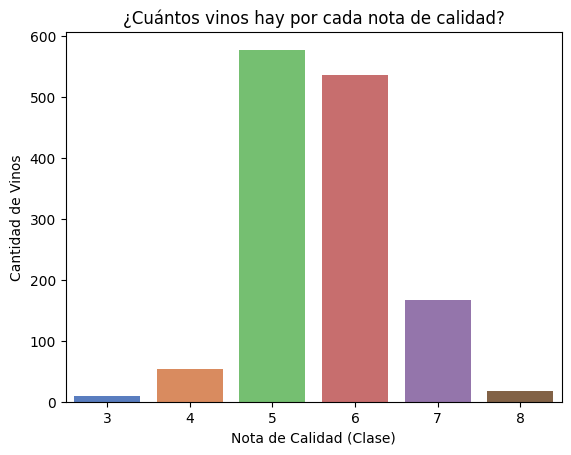

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [51]:
# Gráfico de barras simple para ver las categorías de calidad
sns.countplot(data=df, x='quality', palette='muted')
plt.title('¿Cuántos vinos hay por cada nota de calidad?')
plt.xlabel('Nota de Calidad (Clase)')
plt.ylabel('Cantidad de Vinos')
plt.show()

# Vemos los números exactos
print(df['quality'].value_counts().sort_index())

### Análisis de la distribución de calidad:
El gráfico nos muestra claramente que el dataset está **desbalanceado**. Casi todos los vinos tienen nota 5 o 6, y hay muy poquitos vinos calificados con nota 3 u 8 (los extremos).

* **Impacto técnico:** Si entrenamos un modelo con esto y usamos la métrica de exactitud común (Accuracy), el modelo se puede volver "flojo": predecirá que casi todo es nota 5 o 6 para acertar la mayoría de las veces, pero fallará por completo al encontrar los vinos muy buenos o muy malos.
* **Estrategia para las próximas fases:** Por esta razón, cuando tengamos que evaluar los modelos en las fases de evaluación, no nos vamos a guiar solo por el Accuracy. Le daremos prioridad al **F1-Score ponderado (Weighted F1-Score)** y miraremos las Matrices de Confusión para asegurarnos de que el modelo también aprenda a identificar las notas que tienen menos muestras.

## 6. Matriz de Correlación
Para cerrar la exploración, veremos un mapa de calor que nos indica qué variables se relacionan más entre sí y cuáles influyen de forma directa en la nota de calidad.

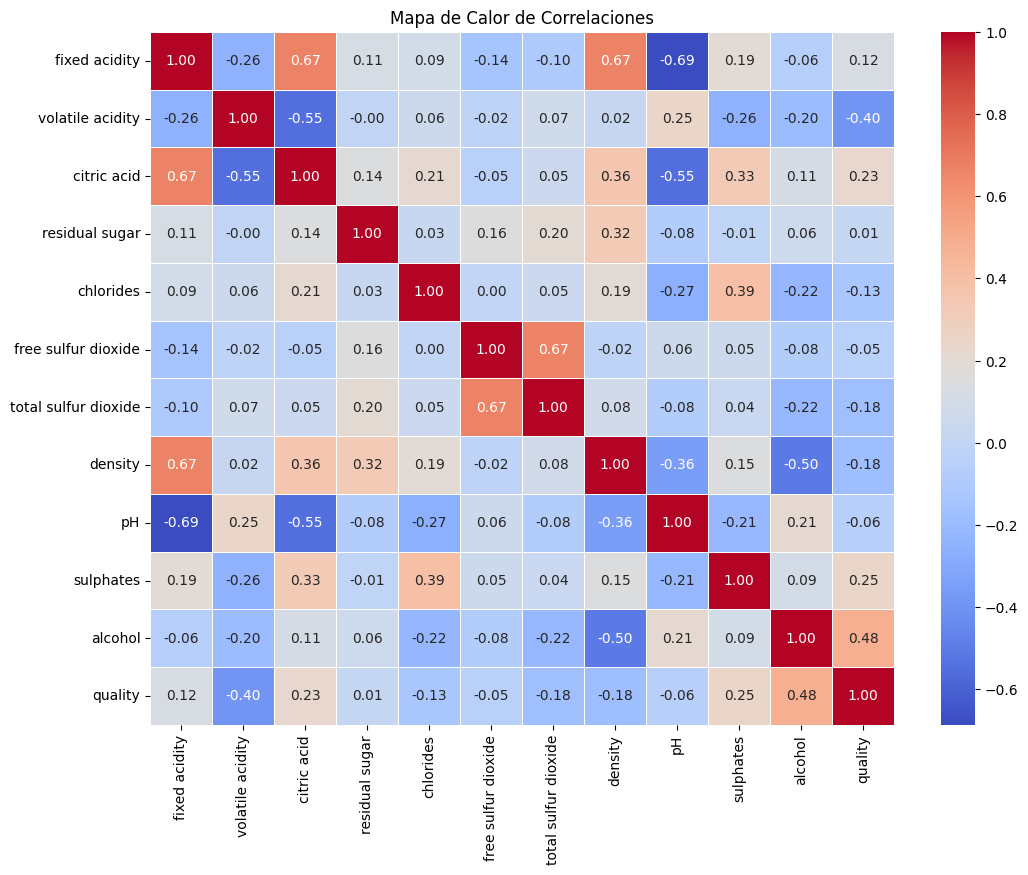

In [52]:
# Calculamos las correlaciones de Pearson entre columnas
correlaciones = df.corr()

# Dibujamos el Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

### Principales conclusiones del Mapa de Calor:
1. **El Alcohol importa:** El alcohol tiene la relación positiva más alta con la calidad (+0.48). Esto nos dice que, por lo general, los vinos que tienen un grado de alcohol un poco más alto reciben mejores notas de calidad.
2. **La Acidez Volátil resta:** La acidez volátil tiene una relación negativa importante con la calidad (-0.39). Esto tiene mucho sentido con el producto: la acidez volátil alta da un sabor parecido al vinagre, por lo que mientras más tenga, peor va a ser la nota del vino.
3. **Variables unidas (Multicolinealidad):** Vemos que la acidez fija (`fixed acidity`) se relaciona mucho con el ácido cítrico (`citric acid`) con un +0.67. Es una alerta que debemos considerar si usamos modelos que se confunden cuando dos columnas explican casi lo mismo.

In [53]:
# Exportamos el DataFrame limpio para que los próximos archivos del proyecto lo usen de forma automática
ruta_salida = 'data/processed/winequality_clean.csv'
df.to_csv(ruta_salida, index=False)

print(f"Fase 1 terminada. Archivo limpio guardado en: {ruta_salida}")
print(f"Total de registros listos para el modelado: {df.shape[0]}")

OSError: Cannot save file into a non-existent directory: 'data/processed'